# Libraries and functions

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def _extract_metric_at_epoch(eval_epochs, metric_values, epoch=None):
    eval_epochs = np.asarray(eval_epochs)
    metric_values = np.asarray(metric_values, dtype=float)

    if metric_values.size == 0:
        return np.nan

    if epoch is None:
        return float(metric_values[-1])

    matches = np.where(eval_epochs == epoch)[0]
    if len(matches) == 0:
        return np.nan
    return float(metric_values[matches[-1]])


def available_common_epochs(data):
    epochs_list = []
    for arr in data["eval_epochs"]:
        arr = np.asarray(arr, dtype=int)
        if arr.size > 0:
            epochs_list.append(set(arr.tolist()))

    if not epochs_list:
        return []

    common = set.intersection(*epochs_list)
    return sorted(common)


def build_phase_diagram_arrays(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
):
    data = np.load(npz_path, allow_pickle=True)

    lr = np.asarray(data["lr"], dtype=float)
    inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

    lr_vals = np.sort(np.unique(lr))
    inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

    # y-axis = lr, x-axis = inv_sigma_w
    phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
    counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

    scalar_metric_keys = {
        "final_train_loss_std_mse",
        "final_test_loss_std_mse",
        "final_train_mae_years",
        "final_test_mae_years",
        "final_train_mse_years",
        "final_test_mse_years",
    }

    for i_lr, lr_val in enumerate(lr_vals):
        for j_inv, inv_val in enumerate(inv_sigma_vals):
            mask = (lr == lr_val) & (inv_sigma_w == inv_val)
            idxs = np.where(mask)[0]

            vals = []
            for idx in idxs:
                if metric_key in scalar_metric_keys:
                    v = float(data[metric_key][idx])
                else:
                    eval_epochs = data["eval_epochs"][idx]
                    metric_values = data[metric_key][idx]
                    v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

                if np.isfinite(v):
                    vals.append(v)
                if v>100:
                    vals.append(100)

            if len(vals) > 0:
                phase_matrix[i_lr, j_inv] = float(np.mean(vals))
                counts_matrix[i_lr, j_inv] = len(vals)

    return inv_sigma_vals, lr_vals, phase_matrix, counts_matrix


def plot_phase_diagram_imshow(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
    title=None,
    annotate=False,
    figsize=(6, 5),
):
    inv_sigma_vals, lr_vals, phase_matrix, counts_matrix = build_phase_diagram_arrays(
        npz_path=npz_path,
        metric_key=metric_key,
        epoch=epoch,
    )

    masked = np.ma.masked_invalid(phase_matrix)

    cmap = mpl.colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(np.log(masked), origin="lower", aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(inv_sigma_vals)))
    ax.set_xticklabels([f"{x:g}" for x in inv_sigma_vals], rotation=45)
    ax.set_yticks(np.arange(len(lr_vals)))
    ax.set_yticklabels([f"{x:g}" for x in lr_vals])

    ax.set_xlabel(r"$1/\sigma_w$")
    ax.set_ylabel("learning rate")

    if title is None:
        if epoch is None:
            ax.set_title(f"{metric_key} (last available epoch, mean over seeds)")
        else:
            ax.set_title(f"{metric_key} (epoch={epoch}, mean over seeds)")
    else:
        ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric_key)

    if annotate:
        for i in range(phase_matrix.shape[0]):
            for j in range(phase_matrix.shape[1]):
                txt = "NaN" if np.isnan(phase_matrix[i, j]) else f"{phase_matrix[i, j]:.3g}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    return fig, ax, inv_sigma_vals, lr_vals, phase_matrix, counts_matrix

In [4]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Tuple, List, Any

import numpy as np


def print_lr_inv_sigma_combo_matrix(save_folder: str | Path):
    """
    Read an experiment-2 output folder and print the matrix of (a,b) indices
    for the (lr, inv_sigma_w) combinations found there.

    Convention:
    - a = index of lr in sorted(unique_lrs)
    - b = index of inv_sigma_w in sorted(unique_inv_sigmas)

    Rows correspond to inv_sigma_w values (sorted increasing).
    Columns correspond to lr values (sorted increasing).

    Parameters
    ----------
    save_folder : str or Path
        Folder containing combo_* subfolders produced by experiment 2.

    Returns
    -------
    result : dict with keys
        - matrix_labels: 2D object array with entries like "(a,b)"
        - matrix_combo_index: 2D float array with combo_index where present, nan otherwise
        - unique_lrs: sorted list of lr values
        - unique_inv_sigmas: sorted list of inv_sigma_w values
        - combo_map: dict[(a,b)] -> info
    """
    save_folder = Path(save_folder).expanduser().resolve()
    if not save_folder.exists():
        raise FileNotFoundError(f"Folder not found: {save_folder}")

    combo_dirs = sorted([p for p in save_folder.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found inside {save_folder}")

    records: List[Dict[str, Any]] = []

    for combo_dir in combo_dirs:
        seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
        if not seed_dirs:
            continue

        # Use the first seed folder, since lr and inv_sigma_w are the same for all seeds
        run_spec_path = seed_dirs[0] / "run_spec.json"
        if not run_spec_path.exists():
            continue

        with open(run_spec_path, "r", encoding="utf-8") as f:
            run_spec = json.load(f)

        train = run_spec.get("train", {})
        lr = float(train["lr"])
        inv_sigma_w = float(train["inv_sigma_w"])
        combo_index = int(run_spec.get("combo_index", -1))

        records.append(
            {
                "combo_dir": combo_dir,
                "combo_index": combo_index,
                "lr": lr,
                "inv_sigma_w": inv_sigma_w,
            }
        )

    if not records:
        raise RuntimeError(f"No valid run_spec.json files found under {save_folder}")

    unique_lrs = sorted({r["lr"] for r in records})
    unique_inv_sigmas = sorted({r["inv_sigma_w"] for r in records})

    lr_to_a = {lr: a for a, lr in enumerate(unique_lrs)}
    inv_sigma_to_b = {inv_sigma: b for b, inv_sigma in enumerate(unique_inv_sigmas)}

    n_rows = len(unique_inv_sigmas)
    n_cols = len(unique_lrs)

    matrix_labels = np.full((n_rows, n_cols), "", dtype=object)
    matrix_combo_index = np.full((n_rows, n_cols), np.nan, dtype=float)

    combo_map: Dict[Tuple[int, int], Dict[str, Any]] = {}

    for r in records:
        a = lr_to_a[r["lr"]]
        b = inv_sigma_to_b[r["inv_sigma_w"]]

        # rows = inv_sigma index, cols = lr index
        matrix_labels[b, a] = f"({a},{b})"
        matrix_combo_index[b, a] = r["combo_index"]

        combo_map[(a, b)] = {
            "combo_index": r["combo_index"],
            "lr": r["lr"],
            "inv_sigma_w": r["inv_sigma_w"],
            "combo_dir": str(r["combo_dir"]),
        }

    print("\nColumns = lr values")
    for a, lr in enumerate(unique_lrs):
        print(f"  a={a}: lr={lr}")

    print("\nRows = inv_sigma_w values")
    for b, inv_sigma in enumerate(unique_inv_sigmas):
        print(f"  b={b}: inv_sigma_w={inv_sigma}")

    print("\nMatrix of (a,b) labels  [rows = inv_sigma_w, cols = lr]:\n")
    print(matrix_labels)

    print("\nMatrix of combo_index  [rows = inv_sigma_w, cols = lr]:\n")
    print(matrix_combo_index)

    return {
        "matrix_labels": matrix_labels,
        "matrix_combo_index": matrix_combo_index,
        "unique_lrs": unique_lrs,
        "unique_inv_sigmas": unique_inv_sigmas,
        "combo_map": combo_map,
    }

In [5]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Tuple, List, Any, Sequence

import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_svd_histograms_for_combo(
    save_folder: str | Path,
    combo: Tuple[int, int],
    epochs: Sequence[int],
    *,
    which: str = "weight",
    seed: int | None = None,
    svd_filename: str = "svd_diagnostics.pt",
    bins: int = 30,
    density: bool = False,
    log_x: bool = False,
    log_y: bool = False,
    figsize_per_panel: Tuple[float, float] = (4.5, 2.8),
):
    """
    Plot histograms of saved SVD singular values for one combo (a,b) at selected epochs.

    Parameters
    ----------
    save_folder : str or Path
        Root experiment folder containing combo_* directories.
    combo : tuple[int, int]
        (a,b) where
        - a = index in sorted unique lr values
        - b = index in sorted unique inv_sigma_w values
    epochs : sequence[int]
        Epochs to plot, e.g. [1, 10, 100]
    which : {"weight", "grad"}
        Whether to plot weight singular values or gradient singular values.
    seed : int or None
        If None, uses the first seed folder found inside the combo folder.
        Otherwise selects the seed_<seed>_* folder.
    svd_filename : str
        Name of the saved SVD diagnostics file.
    bins : int
        Number of histogram bins.
    density : bool
        Passed to matplotlib hist.
    log_x : bool
        If True, x axis is logarithmic when possible.
    log_y : bool
        If True, y axis is logarithmic.
    figsize_per_panel : tuple[float, float]
        Size multiplier per subplot.

    Returns
    -------
    out : dict
        Contains figure, axes, combo info, and loaded diagnostics.
    """
    if which not in {"weight", "grad"}:
        raise ValueError("which must be 'weight' or 'grad'.")

    save_folder = Path(save_folder).expanduser().resolve()
    epochs = [int(e) for e in epochs]
    a, b = int(combo[0]), int(combo[1])

    # ------------------------------------------------------------------
    # Step 1: reconstruct mapping (a,b) -> combo_dir using run_spec.json
    # ------------------------------------------------------------------
    combo_dirs = sorted([p for p in save_folder.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found in {save_folder}")

    records: List[Dict[str, Any]] = []
    for combo_dir in combo_dirs:
        seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
        if not seed_dirs:
            continue

        run_spec_path = seed_dirs[0] / "run_spec.json"
        if not run_spec_path.exists():
            continue

        with open(run_spec_path, "r", encoding="utf-8") as f:
            run_spec = json.load(f)

        train = run_spec.get("train", {})
        if "lr" not in train or "inv_sigma_w" not in train:
            continue

        records.append(
            {
                "combo_dir": combo_dir,
                "lr": float(train["lr"]),
                "inv_sigma_w": float(train["inv_sigma_w"]),
                "combo_index": int(run_spec.get("combo_index", -1)),
            }
        )

    if not records:
        raise RuntimeError(f"No valid run_spec.json found under {save_folder}")

    unique_lrs = sorted({r["lr"] for r in records})
    unique_inv_sigmas = sorted({r["inv_sigma_w"] for r in records})

    if not (0 <= a < len(unique_lrs)):
        raise IndexError(f"a={a} out of range. Valid range: 0..{len(unique_lrs)-1}")
    if not (0 <= b < len(unique_inv_sigmas)):
        raise IndexError(f"b={b} out of range. Valid range: 0..{len(unique_inv_sigmas)-1}")

    target_lr = unique_lrs[a]
    target_inv_sigma = unique_inv_sigmas[b]

    matched = [
        r for r in records
        if r["lr"] == target_lr and r["inv_sigma_w"] == target_inv_sigma
    ]
    if len(matched) == 0:
        raise RuntimeError(f"No combo folder found for combo (a,b)=({a},{b})")

    if len(matched) > 1:
        raise RuntimeError(f"More than one combo folder matched combo (a,b)=({a},{b})")

    combo_info = matched[0]
    combo_dir = combo_info["combo_dir"]

    # ------------------------------------------------------------------
    # Step 2: choose seed folder
    # ------------------------------------------------------------------
    seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
    if not seed_dirs:
        raise RuntimeError(f"No seed_* folders found in {combo_dir}")

    if seed is None:
        seed_dir = seed_dirs[0]
    else:
        candidates = [p for p in seed_dirs if p.name.startswith(f"seed_{int(seed):04d}_")]
        if not candidates:
            raise RuntimeError(f"No seed folder found for seed={seed} in {combo_dir}")
        seed_dir = candidates[0]

    svd_path = seed_dir / svd_filename
    if not svd_path.exists():
        raise FileNotFoundError(
            f"SVD diagnostics file not found:\n{svd_path}\n"
            f"Did you run the experiment with COMPUTE_SVD_DIAGNOSTICS=1?"
        )

    d = torch.load(svd_path, map_location="cpu")

    by_epoch = d.get("by_epoch", {})
    if not by_epoch:
        raise RuntimeError(f"No 'by_epoch' data found inside {svd_path}")

    # ------------------------------------------------------------------
    # Step 3: determine layer order from first requested available epoch
    # ------------------------------------------------------------------
    first_epoch_key = None
    for ep in epochs:
        ep_key = str(int(ep))
        if ep_key in by_epoch:
            first_epoch_key = ep_key
            break
    if first_epoch_key is None:
        available = sorted(int(k) for k in by_epoch.keys())
        raise RuntimeError(
            f"None of the requested epochs {list(epochs)} are present.\n"
            f"Available epochs: {available}"
        )

    layer_order = by_epoch[first_epoch_key].get("layer_order", None)
    if not layer_order:
        layer_order = sorted(by_epoch[first_epoch_key]["layers"].keys())

    n_layers = len(layer_order)
    n_epochs = len(epochs)

    fig_w = figsize_per_panel[0] * n_epochs
    fig_h = figsize_per_panel[1] * n_layers
    fig, axes = plt.subplots(n_layers, n_epochs, figsize=(fig_w, fig_h), squeeze=False)

    value_key = "weight_singular_values" if which == "weight" else "grad_singular_values"

    # ------------------------------------------------------------------
    # Step 4: plot
    # ------------------------------------------------------------------
    for i, layer_name in enumerate(layer_order):
        for j, ep in enumerate(epochs):
            ax = axes[i, j]
            ep_key = str(int(ep))

            if ep_key not in by_epoch:
                ax.text(0.5, 0.5, f"epoch {ep}\nmissing", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            epoch_layers = by_epoch[ep_key]["layers"]
            if layer_name not in epoch_layers:
                ax.text(0.5, 0.5, f"{layer_name}\nmissing", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            values = np.asarray(epoch_layers[layer_name][value_key], dtype=float)

            finite_mask = np.isfinite(values)
            values = values[finite_mask]

            if values.size == 0:
                ax.text(0.5, 0.5, "no finite values", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            # If log_x, keep only strictly positive values
            if log_x:
                values = values[values > 0.0]
                if values.size == 0:
                    ax.text(0.5, 0.5, "no positive values\nfor log-x", ha="center", va="center")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

            ax.hist(values, bins=bins, density=density)

            if log_x:
                ax.set_xscale("log")
            if log_y:
                ax.set_yscale("log")

            if i == 0:
                ax.set_title(f"epoch {ep}", fontsize=11)

            if j == 0:
                ax.set_ylabel(layer_name, fontsize=10)

            if i == n_layers - 1:
                if which == "weight":
                    ax.set_xlabel("weight singular value")
                else:
                    ax.set_xlabel("gradient singular value")

    fig.suptitle(
        f"SVD histograms for combo (a,b)=({a},{b}) | "
        f"lr={target_lr:g}, inv_sigma_w={target_inv_sigma:g} | "
        f"seed_dir={seed_dir.name} | which={which}",
        fontsize=12,
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    return {
        "figure": fig,
        "axes": axes,
        "combo_dir": combo_dir,
        "seed_dir": seed_dir,
        "svd_path": svd_path,
        "diagnostics": d,
        "layer_order": layer_order,
        "unique_lrs": unique_lrs,
        "unique_inv_sigmas": unique_inv_sigmas,
        "target_lr": target_lr,
        "target_inv_sigma_w": target_inv_sigma,
    }

# Experiment 2 - DNN

## SGD - 1 hidden

### Relu

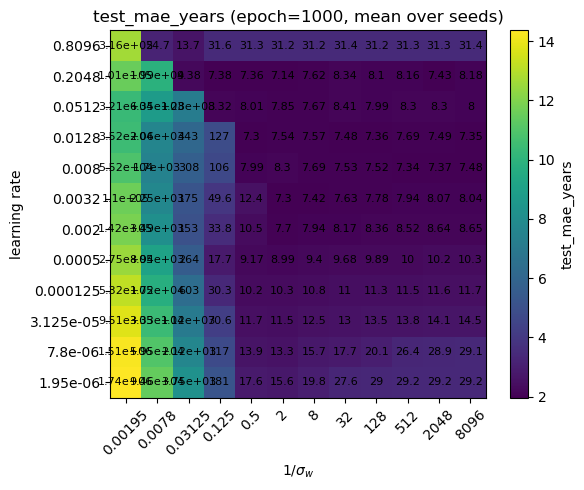

In [13]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/conductivity_SVD_dnn_SMALL_sgd_relu_v4.npz",
    metric_key="test_mae_years",
    epoch= 1000,
    annotate=True,
)
plt.show()

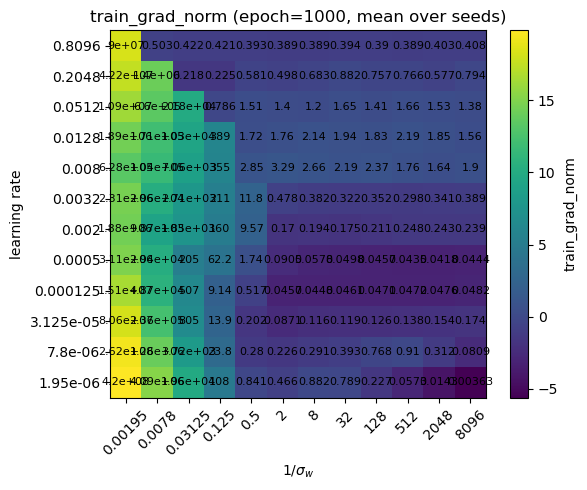

In [14]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/conductivity_SVD_dnn_SMALL_sgd_relu_v4.npz",
    metric_key="train_grad_norm",
    epoch= 1000,
    annotate=True,
)
plt.show()

#### Full batch

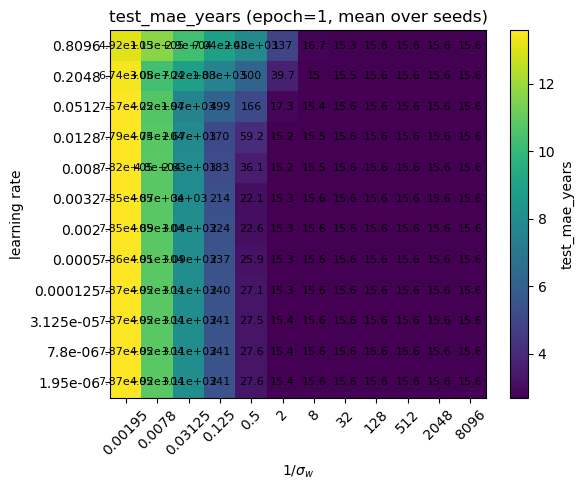

In [36]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

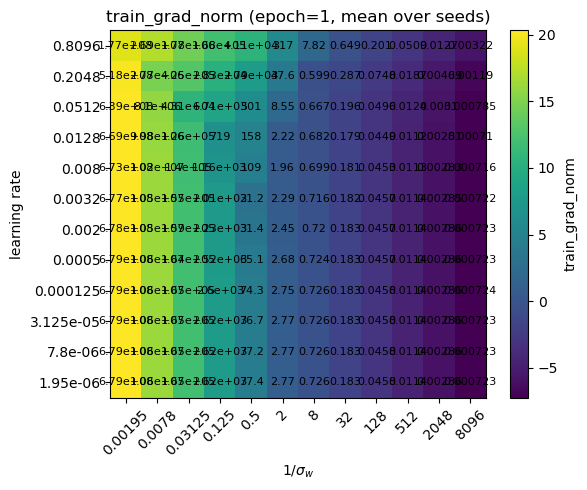

In [37]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

### tanh

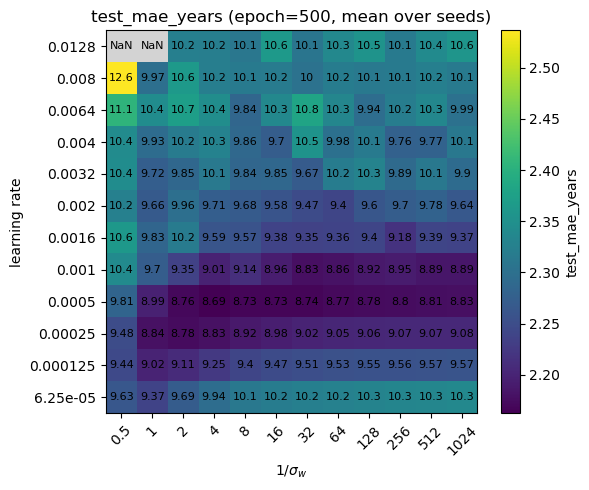

In [38]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_v1_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

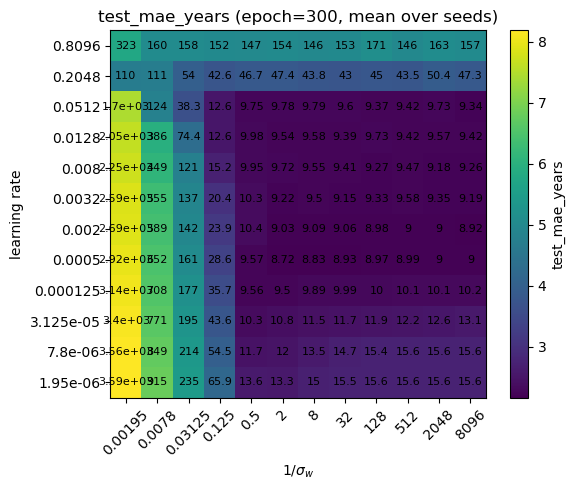

In [39]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

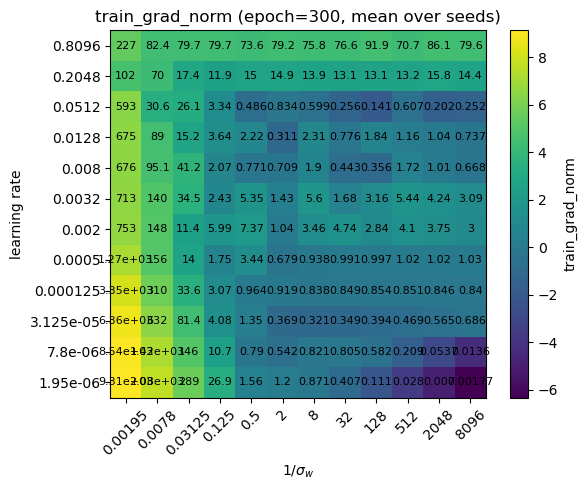

In [40]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

#### Full batch

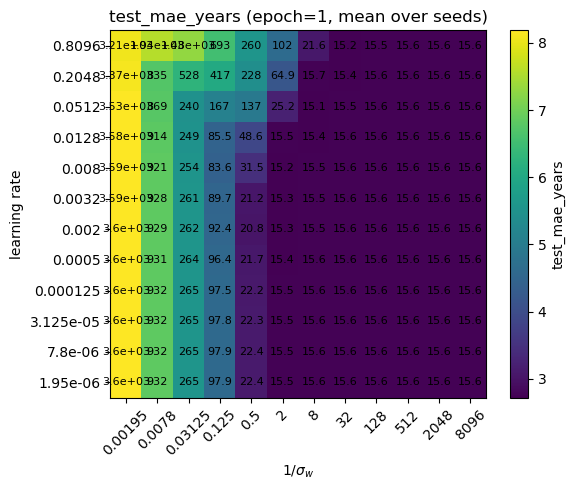

In [41]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

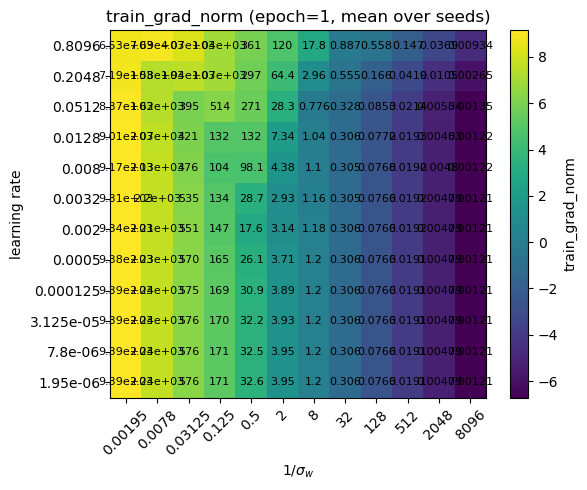

In [42]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

## SGD - three hidden

### relu

#### Minibatch

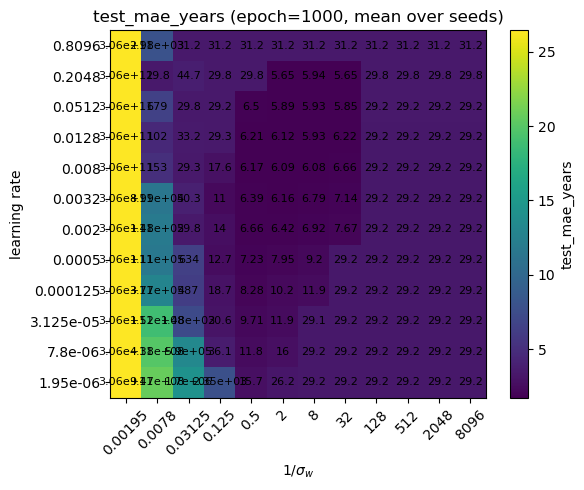

In [16]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/conductivity_SVD_dnn_BIG_sgd_relu_v4.npz",
    metric_key="test_mae_years",
    epoch= 1000,
    annotate=True,
)
plt.show()

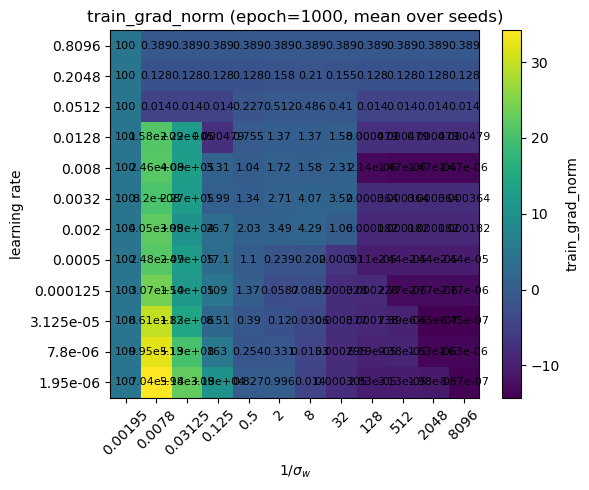

In [17]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/conductivity_SVD_dnn_BIG_sgd_relu_v4.npz",
    metric_key="train_grad_norm",
    epoch= 1000,
    annotate=True,
)
plt.show()

#### Full batch

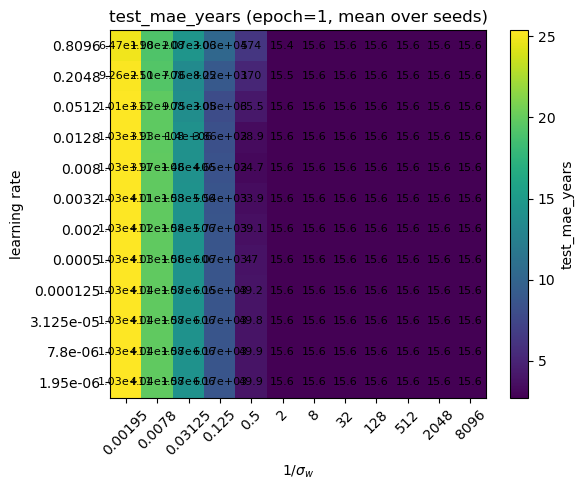

In [46]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

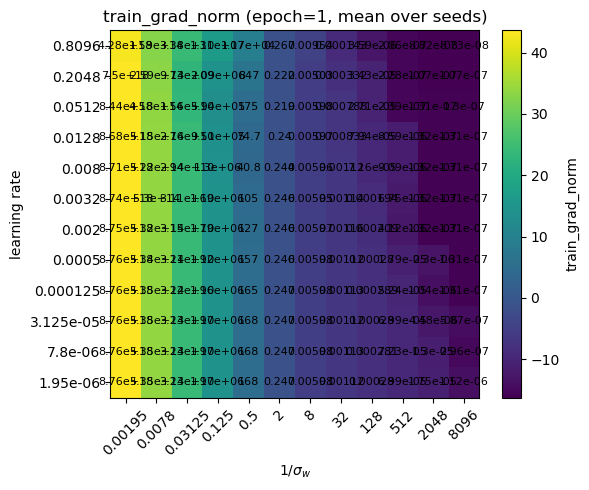

In [47]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

#### minibatch, SVD

In [6]:
out = print_lr_inv_sigma_combo_matrix("data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1")


Columns = lr values
  a=0: lr=1.95e-06
  a=1: lr=0.000125
  a=2: lr=0.008
  a=3: lr=0.0512
  a=4: lr=0.8096

Rows = inv_sigma_w values
  b=0: inv_sigma_w=0.00195
  b=1: inv_sigma_w=0.125
  b=2: inv_sigma_w=8.0
  b=3: inv_sigma_w=512.0
  b=4: inv_sigma_w=8096.0

Matrix of (a,b) labels  [rows = inv_sigma_w, cols = lr]:

[['(0,0)' '(1,0)' '(2,0)' '(3,0)' '(4,0)']
 ['(0,1)' '(1,1)' '(2,1)' '(3,1)' '(4,1)']
 ['(0,2)' '(1,2)' '(2,2)' '(3,2)' '(4,2)']
 ['(0,3)' '(1,3)' '(2,3)' '(3,3)' '(4,3)']
 ['(0,4)' '(1,4)' '(2,4)' '(3,4)' '(4,4)']]

Matrix of combo_index  [rows = inv_sigma_w, cols = lr]:

[[ 0.  1.  2.  3.  4.]
 [ 5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14.]
 [15. 16. 17. 18. 19.]
 [20. 21. 22. 23. 24.]]


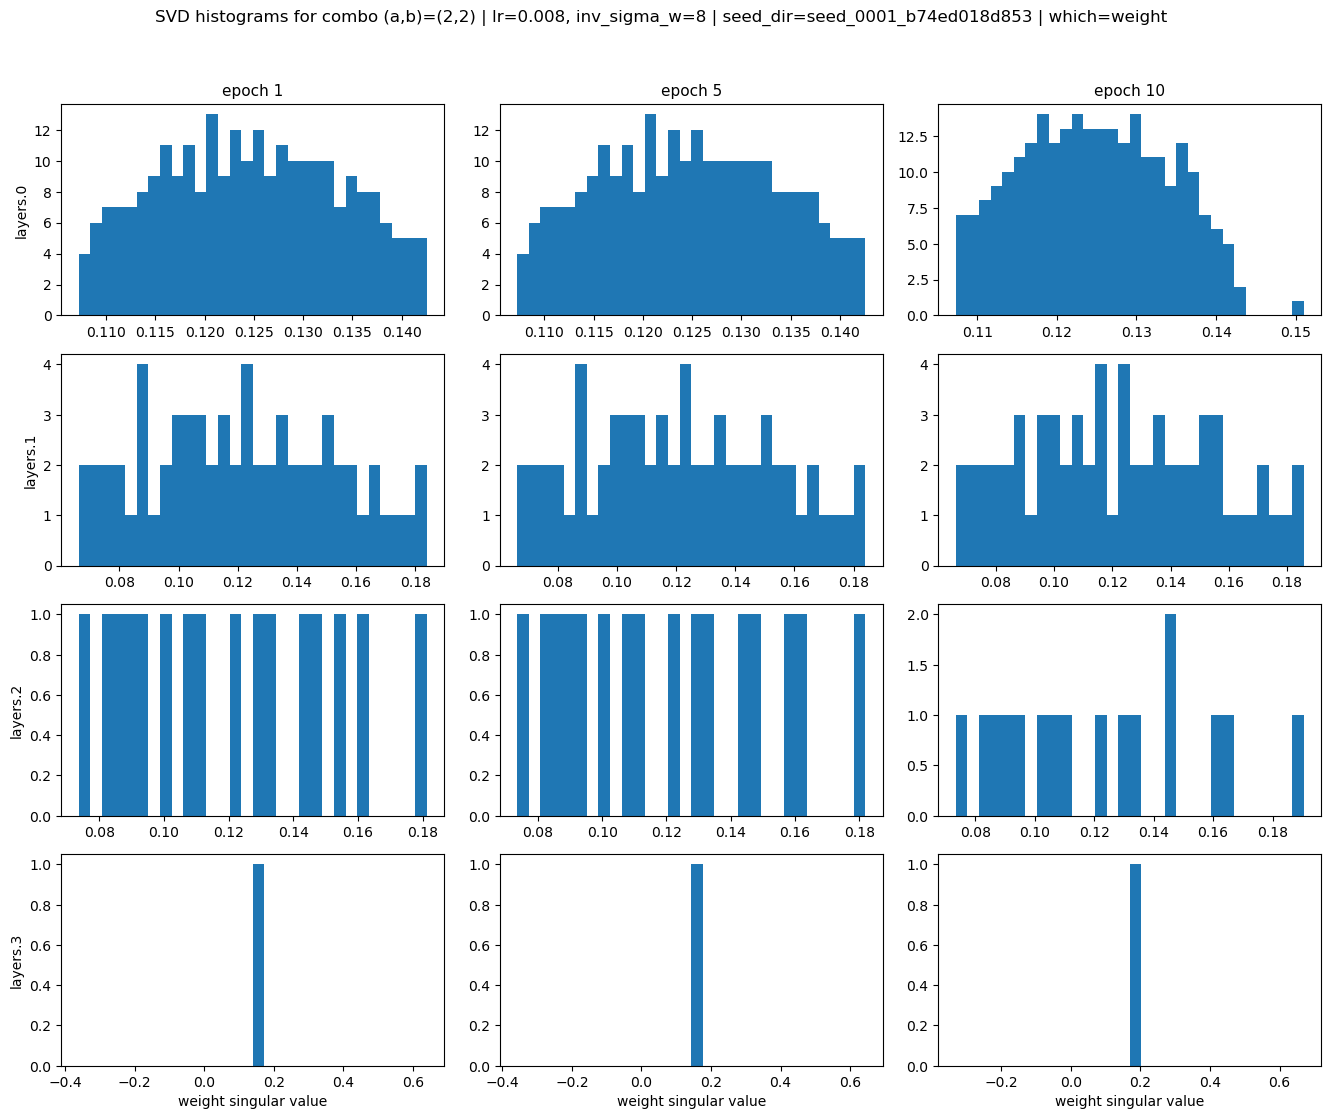

In [14]:
out = plot_svd_histograms_for_combo(
    "data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1",
    combo=(2, 2),
    epochs=[1, 5, 10],
    which="weight",
)
plt.show()

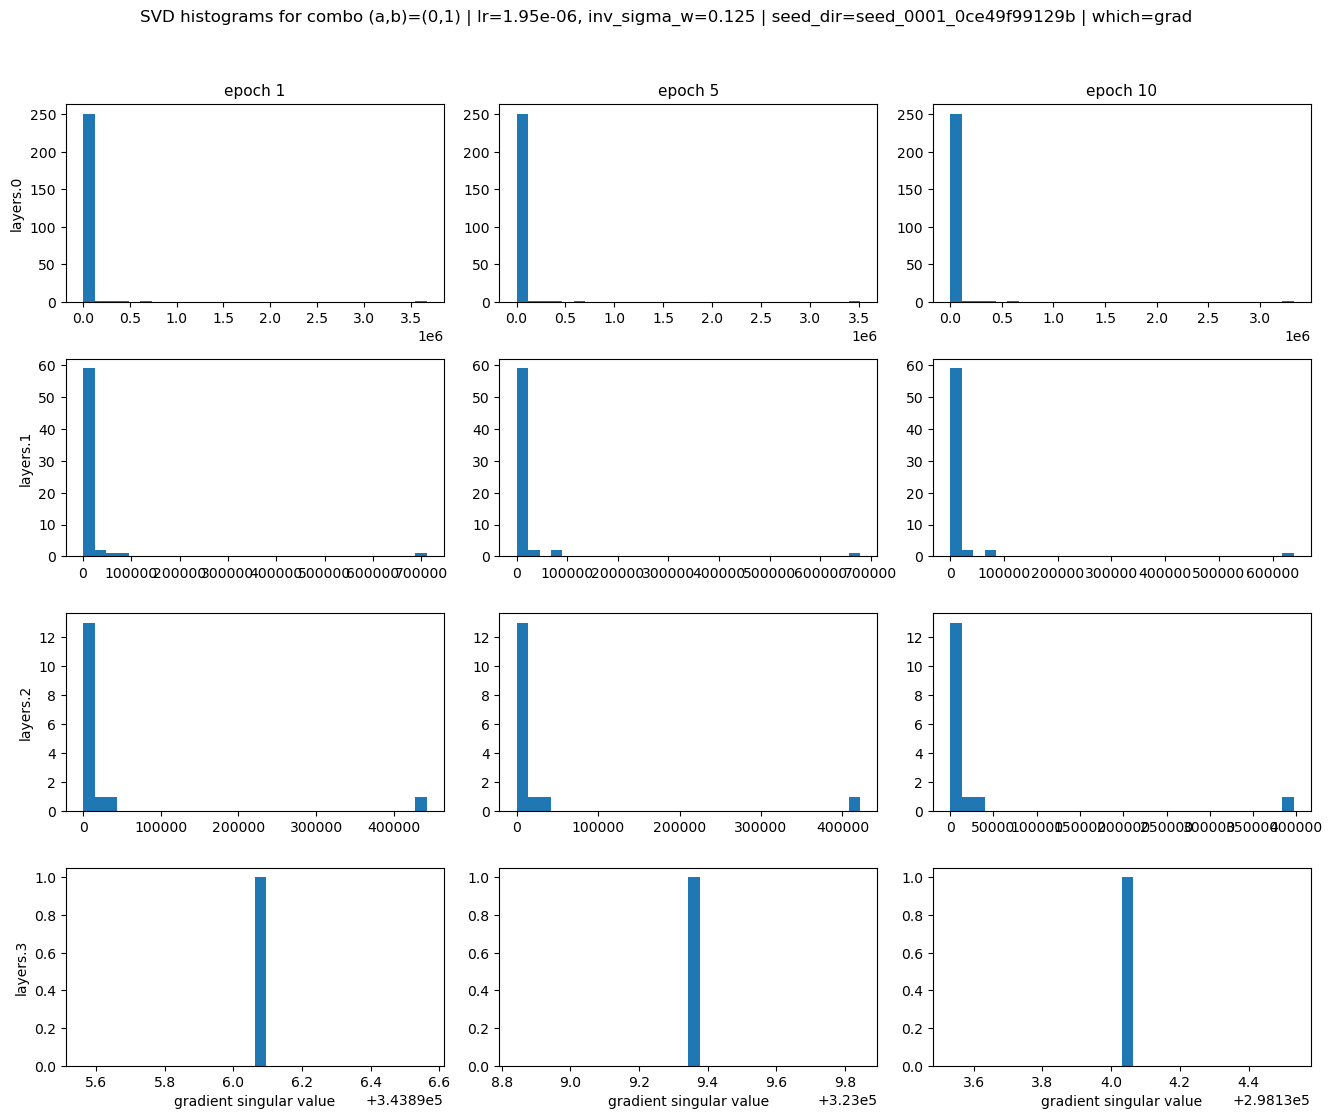

In [19]:
out = plot_svd_histograms_for_combo(
    "data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1",
    combo=(0,1),
    epochs=[1, 5, 10],
    which="grad",
)
plt.show()

### tanh

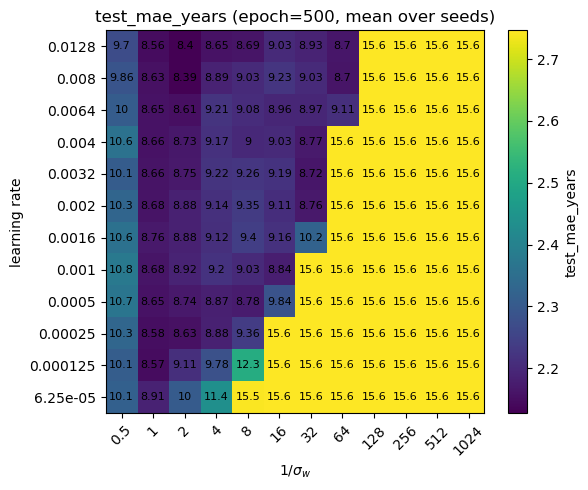

In [48]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

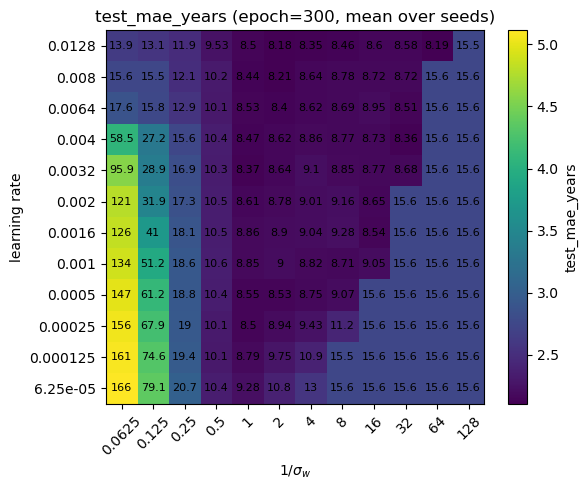

In [49]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

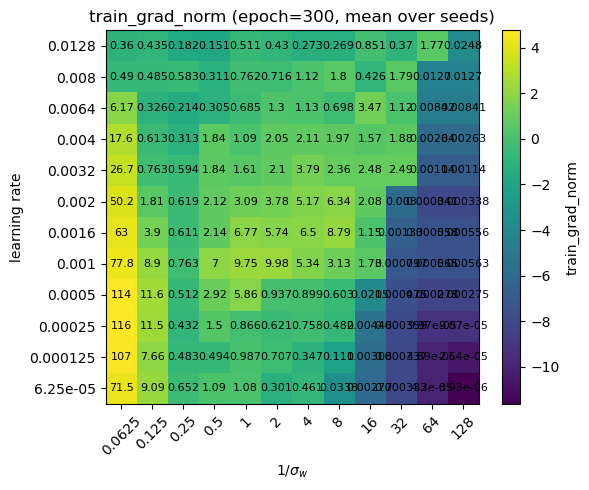

In [50]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

#### Full batch

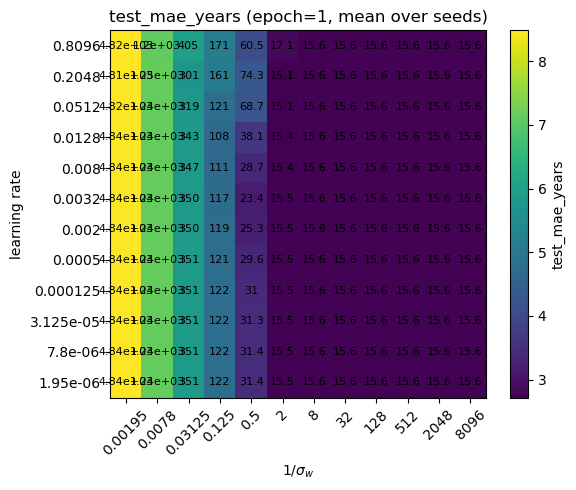

In [51]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

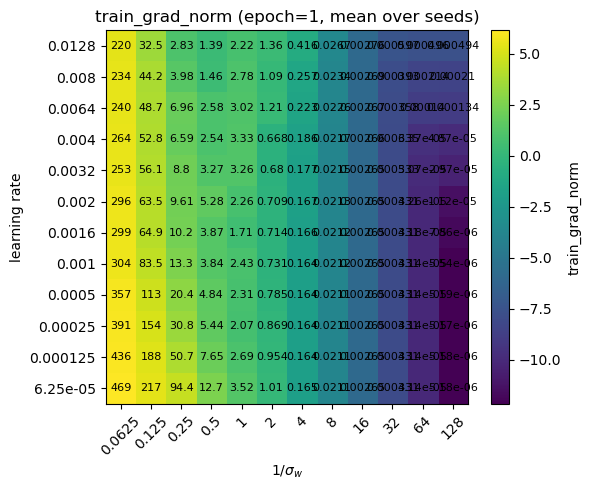

In [52]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()